In [ ]:
!pip install timm torch torchvision matplotlib seaborn scikit-learn tqdm pillow gradio gdown -q

In [ ]:
import os, json, random, copy, glob, shutil, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from scipy.ndimage import uniform_filter1d

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import timm

from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score
)
from sklearn.preprocessing import label_binarize

import gdown
import gradio as gr

In [ ]:
# Clone dataset repo from GitHub
!git clone https://github.com/Mostafa-Ashraf-1/Artificial-Neural-Networks-Project-Dead-Neurons-.git

DATASET_ROOT = '/content/Artificial-Neural-Networks-Project-Dead-Neurons-/classifier_dataset'
TRAIN_DIR    = os.path.join(DATASET_ROOT, 'train')
TEST_DIR     = os.path.join(DATASET_ROOT, 'test')

print('Train dir:', TRAIN_DIR)
print('Test  dir:', TEST_DIR)
print('Classes  :', sorted(os.listdir(TRAIN_DIR)))

Cloning into 'Artificial-Neural-Networks-Project-Dead-Neurons-'...
remote: Enumerating objects: 15239, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 15239 (delta 1), reused 0 (delta 0), pack-reused 15228 (from 3)
Receiving objects: 100% (15239/15239), 441.34 MiB | 24.23 MiB/s, done.
Resolving deltas: 100% (749/749), done.
Updating files: 100% (13714/13714), done.
Train dir: /content/Artificial-Neural-Networks-Project-Dead-Neurons-/classifier_dataset/train
Test  dir: /content/Artificial-Neural-Networks-Project-Dead-Neurons-/classifier_dataset/test
Classes  : ['Cardboard', 'Clothes', 'Garbage_bag', 'Glass', 'Metal', 'Organic', 'Plastics']


In [ ]:


warnings.filterwarnings('ignore')

# ── Seeds ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Hyperparameters ──
IMG_SIZE       = 224
BATCH_SIZE     = 32
NUM_CLASSES    = 7
NUM_WORKERS    = 2
VAL_SPLIT      = 0.15
LEARNING_RATE  = 3e-4
WEIGHT_DECAY   = 1e-4
MIN_EPOCHS     = 40
MAX_EPOCHS     = 60
EARLY_STOP_PAT = 10
LR_SCHEDULER_T0 = 10

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# ── Class names — indices 0 to 6 (alphabetical) ──
CLASS_NAMES = ['Cardboard', 'Clothes', 'Garbage_bag', 'Glass', 'Metal', 'Organic', 'Plastics']
CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}
print('Class → Index:', CLASS_TO_IDX)

Device: cpu
Class → Index: {'Cardboard': 0, 'Clothes': 1, 'Garbage_bag': 2, 'Glass': 3, 'Metal': 4, 'Organic': 5, 'Plastics': 6}


In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Training: with augmentation
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomRotation(degrees=20),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.1),
])

# Val / Test: no augmentation
val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ── Load train and val as SEPARATE dataset objects to avoid transform leak ──
train_dataset_aug   = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transforms)
val_dataset_clean   = datasets.ImageFolder(root=TRAIN_DIR, transform=val_test_transforms)

# Verify class order matches expected
found = list(train_dataset_aug.class_to_idx.keys())
assert found == CLASS_NAMES, f'Class mismatch!\n  Expected: {CLASS_NAMES}\n  Found: {found}'

# Shuffle indices with fixed seed then split
all_indices = list(range(len(train_dataset_aug)))
rng = random.Random(SEED)
rng.shuffle(all_indices)
val_size   = int(len(all_indices) * VAL_SPLIT)
val_idx    = all_indices[:val_size]
train_idx  = all_indices[val_size:]

train_subset = Subset(train_dataset_aug, train_idx)
val_subset   = Subset(val_dataset_clean, val_idx)

# Test dataset
test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=val_test_transforms)

# Count per-class images for class weights
class_counts = []
for cls in CLASS_NAMES:
    p = os.path.join(TRAIN_DIR, cls)
    class_counts.append(len([f for f in os.listdir(p)
                              if f.lower().endswith(('.jpg','.jpeg','.png','.bmp'))]))

# DataLoaders
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_subset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train: {len(train_subset)} | Val: {len(val_subset)} | Test: {len(test_dataset)}')

Train: 10310 | Val: 1819 | Test: 635


In [ ]:
def build_convnext_tiny(num_classes, drop_rate=0.3):
    """ConvNeXt-Tiny with pretrained ImageNet weights and custom head."""
    model = timm.create_model('convnext_tiny', pretrained=True, num_classes=0)
    feature_dim = model.num_features  # 768
    model.head = nn.Sequential(
        nn.AdaptiveAvgPool2d(1),
        nn.Flatten(),
        nn.LayerNorm(feature_dim),
        nn.Dropout(p=drop_rate),
        nn.Linear(feature_dim, num_classes)
    )
    return model

model = build_convnext_tiny(NUM_CLASSES, drop_rate=0.3).to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total:,}')
print(f'Trainable params: {trainable:,}')

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Total params    : 27,825,511
Trainable params: 27,825,511


In [ ]:
# Class-weighted loss to handle imbalance
class_weights = torch.tensor([1.0 / c for c in class_counts], dtype=torch.float32)
class_weights = (class_weights / class_weights.sum() * NUM_CLASSES).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=LR_SCHEDULER_T0, T_mult=2, eta_min=1e-6
)

print('Loss: CrossEntropyLoss | Optimizer: AdamW | Scheduler: CosineAnnealingWarmRestarts')

Loss: CrossEntropyLoss | Optimizer: AdamW | Scheduler: CosineAnnealingWarmRestarts


In [ ]:


FOLDER_ID    = '1AFYW6lVlIU09DoCJ7UWuuP3r-VBHIxk6'
WEIGHTS_PATH = 'best_convnext_tiny.pth'
HISTORY_PATH = 'training_history.json'

# Download weights folder if not already present
if not os.path.exists(WEIGHTS_PATH):
    print('Downloading weights from Google Drive...')
    gdown.download_folder(id=FOLDER_ID, output='./drive_weights', quiet=False)

    # Move .pth file to working directory
    pth_files = glob.glob('./drive_weights/*.pth')
    if pth_files:
        shutil.copy(pth_files[0], WEIGHTS_PATH)
        print(f'✅ Weights saved to: {WEIGHTS_PATH}')
    else:
        raise FileNotFoundError('No .pth file found in downloaded folder!')

    # Move history JSON if it exists in the folder
    json_files = glob.glob('./drive_weights/*.json')
    if json_files:
        shutil.copy(json_files[0], HISTORY_PATH)
        print(f'✅ History saved to: {HISTORY_PATH}')
else:
    print(f'✅ Weights already exist: {WEIGHTS_PATH}')

# Load weights — supports both raw state_dict and full checkpoint
checkpoint = torch.load(WEIGHTS_PATH, map_location=DEVICE, weights_only=False)

if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
    best_val_loss = checkpoint.get('best_val_loss', 0.0)
else:
    model.load_state_dict(checkpoint)
    best_val_loss = 0.0

model.eval()
print('✅ Model loaded — skipping training.')

# Try to load training history for curve plots
history_loaded = False
if os.path.exists(HISTORY_PATH):
    with open(HISTORY_PATH) as f:
        hist = json.load(f)
    train_losses = hist['train_loss']
    val_losses   = hist['val_loss']
    train_accs   = hist['train_acc']
    val_accs     = hist['val_acc']
    history_loaded = True
    print(f'✅ Training history loaded ({len(train_losses)} epochs)')
else:
    train_losses = val_losses = train_accs = val_accs = []
    print('⚠️  No training_history.json found — loss/accuracy curves will be skipped.')
    print('   Upload training_history.json to /content/ to enable these plots.')

Retrieving folder contents


Processing file 1HAZShQo41x_1vcXoXqQiloeGft4NfZ2x best_convnext_tiny.pth


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1HAZShQo41x_1vcXoXqQiloeGft4NfZ2x
From (redirected): https://drive.google.com/uc?id=1HAZShQo41x_1vcXoXqQiloeGft4NfZ2x&confirm=t&uuid=afcdc1e9-e2cc-41f9-81a4-ebf25aab5b96
To: /content/drive_weights/best_convnext_tiny.pth
100%|██████████| 111M/111M [00:01<00:00, 58.4MB/s]
Download completed


✅ Weights saved to: best_convnext_tiny.pth
✅ Model loaded — skipping training.
⚠️  No training_history.json found — loss/accuracy curves will be skipped.
   Upload training_history.json to /content/ to enable these plots.


In [ ]:
def smooth_curve(values, window=5):
    return uniform_filter1d(values, size=window)

if history_loaded and len(train_losses) > 1:
    epochs_ran = list(range(1, len(train_losses) + 1))
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Loss Curves', fontsize=15, fontweight='bold')

    for ax, losses, title in zip(axes, [train_losses, val_losses], ['train/loss', 'val/loss']):
        ax.plot(epochs_ran, losses, color='#1f77b4', linewidth=1.2,
                marker='o', markersize=3, label='results')
        ax.plot(epochs_ran, smooth_curve(losses), color='#ff7f0e',
                linewidth=2.0, linestyle='--', label='smooth')
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend(fontsize=9)
        ax.spines[['top','right']].set_visible(False)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('loss_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('📊 Loss curves skipped — upload training_history.json to enable.')

📊 Loss curves skipped — upload training_history.json to enable.


In [ ]:
if history_loaded and len(train_accs) > 1:
    epochs_ran = list(range(1, len(train_accs) + 1))
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Accuracy Curves', fontsize=15, fontweight='bold')

    for ax, accs, title in zip(axes, [train_accs, val_accs], ['train/accuracy', 'val/accuracy']):
        ax.plot(epochs_ran, accs, color='#2ca02c', linewidth=1.2,
                marker='o', markersize=3, label='results')
        ax.plot(epochs_ran, smooth_curve(accs), color='#ff7f0e',
                linewidth=2.0, linestyle='--', label='smooth')
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Accuracy (%)')
        ax.legend(fontsize=9)
        ax.spines[['top','right']].set_visible(False)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('accuracy_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('📊 Accuracy curves skipped — upload training_history.json to enable.')

📊 Accuracy curves skipped — upload training_history.json to enable.


In [ ]:
def get_predictions(model, loader, device):
    """Run inference and return labels, predictions, and probabilities."""
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Evaluating'):
            images  = images.to(device)
            outputs = model(images)
            probs   = torch.softmax(outputs, dim=1)
            preds   = probs.argmax(dim=1)
            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

y_true, y_pred, y_probs = get_predictions(model, test_loader, DEVICE)
test_acc = (y_true == y_pred).mean() * 100

print(f'\n✅ Test Accuracy: {test_acc:.2f}%')
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

Evaluating: 100%|██████████| 20/20 [02:30<00:00,  7.53s/it]


✅ Test Accuracy: 44.57%

Classification Report:
              precision    recall  f1-score   support

   Cardboard     0.3529    0.5000    0.4138        72
     Clothes     0.2667    0.3582    0.3057        67
 Garbage_bag     0.8435    0.5000    0.6278       248
       Glass     0.3958    0.4872    0.4368        39
       Metal     0.2336    0.5682    0.3311        44
     Organic     0.3455    0.3654    0.3551        52
    Plastics     0.4186    0.3186    0.3618       113

    accuracy                         0.4457       635
   macro avg     0.4081    0.4425    0.4046       635
weighted avg     0.5409    0.4457    0.4676       635



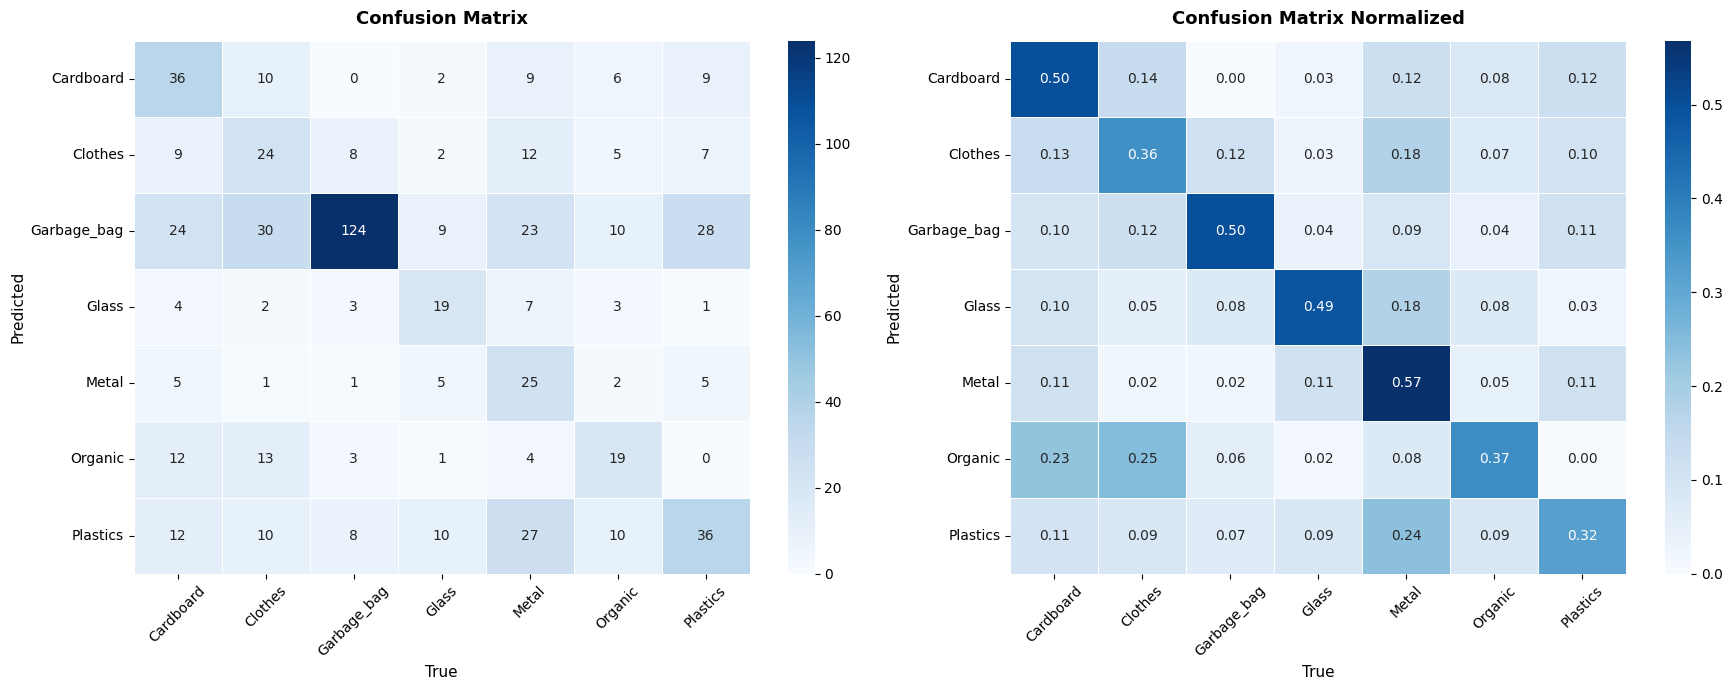

In [ ]:
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, data, title, fmt in zip(
    axes,
    [cm, cm_norm],
    ['Confusion Matrix', 'Confusion Matrix Normalized'],
    ['d', '.2f']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, linecolor='white', ax=ax)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('True',      fontsize=11)
    ax.set_ylabel('Predicted', fontsize=11)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:


def predict_image(pil_img):
    """Preprocess image and return class probabilities."""
    img_tensor = val_test_transforms(pil_img).unsqueeze(0).to(DEVICE)
    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(img_tensor), dim=1).squeeze(0).cpu().numpy()
    return {CLASS_NAMES[i]: float(probs[i]) for i in range(NUM_CLASSES)}

demo = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type='pil', label='Upload Waste Image'),
    outputs=gr.Label(num_top_classes=NUM_CLASSES, label='Classification Results'),
    title='🗑️ Trash Classifier — ConvNeXt-Tiny',
    description=(
        'Upload a waste image to classify it into one of 7 categories:\n'
        'Cardboard (0), Clothes (1), Garbage_bag (2), Glass (3), '
        'Metal (4), Organic (5), Plastics (6)'
    ),
    theme=gr.themes.Soft(),
    allow_flagging='never'
)

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9eca8361d0cd98dda2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
